In [1]:
import numpy as np
import pandas as pd 
import os
os.chdir('..')  # Go up to project root
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input/broad-peak.csv
./kaggle/input/lhotse.csv
./kaggle/input/kangchenjunga.csv
./kaggle/input/.DS_Store
./kaggle/input/cho-oyu.csv
./kaggle/input/everest_20-25.csv
./kaggle/input/manaslu.csv
./kaggle/input/dhaulagiri-I.csv
./kaggle/input/everest.csv
./kaggle/input/k2.csv
./kaggle/input/nanga-parbat.csv
./kaggle/input/gasherbrum-II.csv
./kaggle/input/shishapangma.csv
./kaggle/input/gasherbrum-I.csv
./kaggle/input/annapurna-I.csv
./kaggle/input/makalu.csv


In [2]:
everest20_25 = pd.read_csv('./kaggle/input/everest_20-25.csv')

In [3]:
# Format dates
everest20_25['Date'] = pd.to_datetime(everest20_25['Date'], format='mixed', errors='coerce')
everest20_25['year'] = everest20_25['Date'].dt.year
everest20_25['month'] = everest20_25['Date'].dt.month

# Check if any dates failed to parse
print(f"Missing dates: {everest20_25['Date'].isna().sum()}")

# Deaths per year
everest20_25['year'].value_counts().sort_index()

Missing dates: 0


year
2020    86
2021    93
2022    92
2023    86
2024    73
2025    70
Name: count, dtype: int64

In [11]:
# Format expedition type
everest20_25['expedition_type'] = everest20_25['Expedition_Company'].apply(
    lambda x: 'Independent/Private' if pd.isna(x) or 'Independent' in str(x) or 'Private' in str(x) 
    else 'Commercial Company'
)

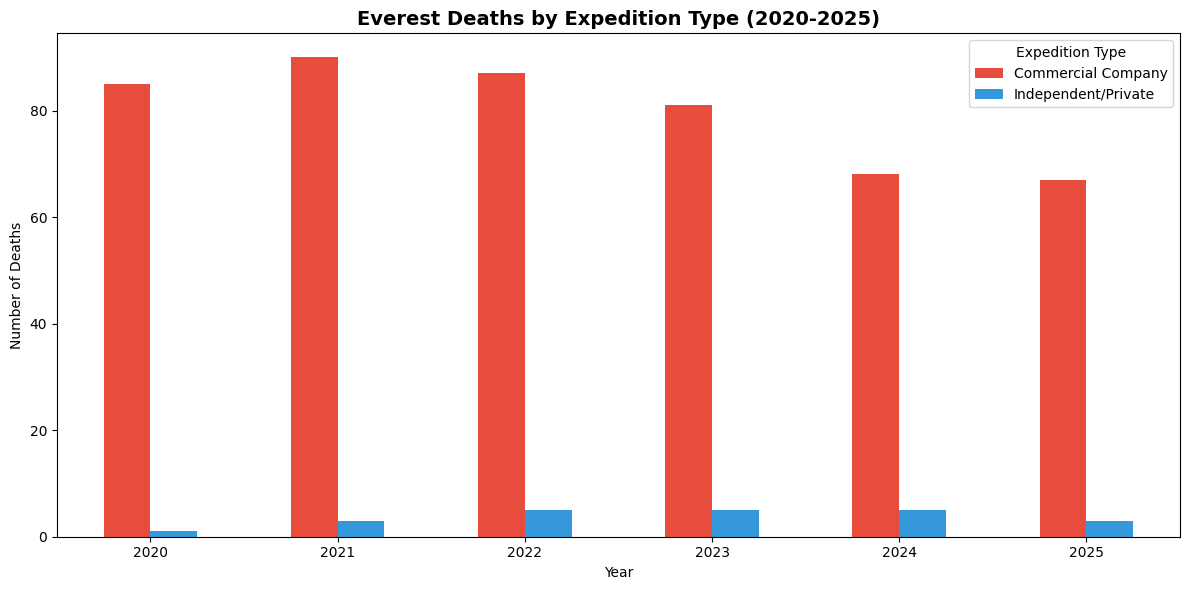

In [12]:
# 1. Deaths: Independent vs Commercial over time
fig, ax = plt.subplots(figsize=(12, 6))
yearly_type = pd.crosstab(everest20_25['year'], everest20_25['expedition_type'])
yearly_type.plot(kind='bar', ax=ax, color=['#e74c3c', '#3498db'])
plt.title('Everest Deaths by Expedition Type (2020-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(title='Expedition Type')
plt.xticks(rotation=0)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_expedition_type_yearly.png', dpi=300, bbox_inches='tight')
plt.show()

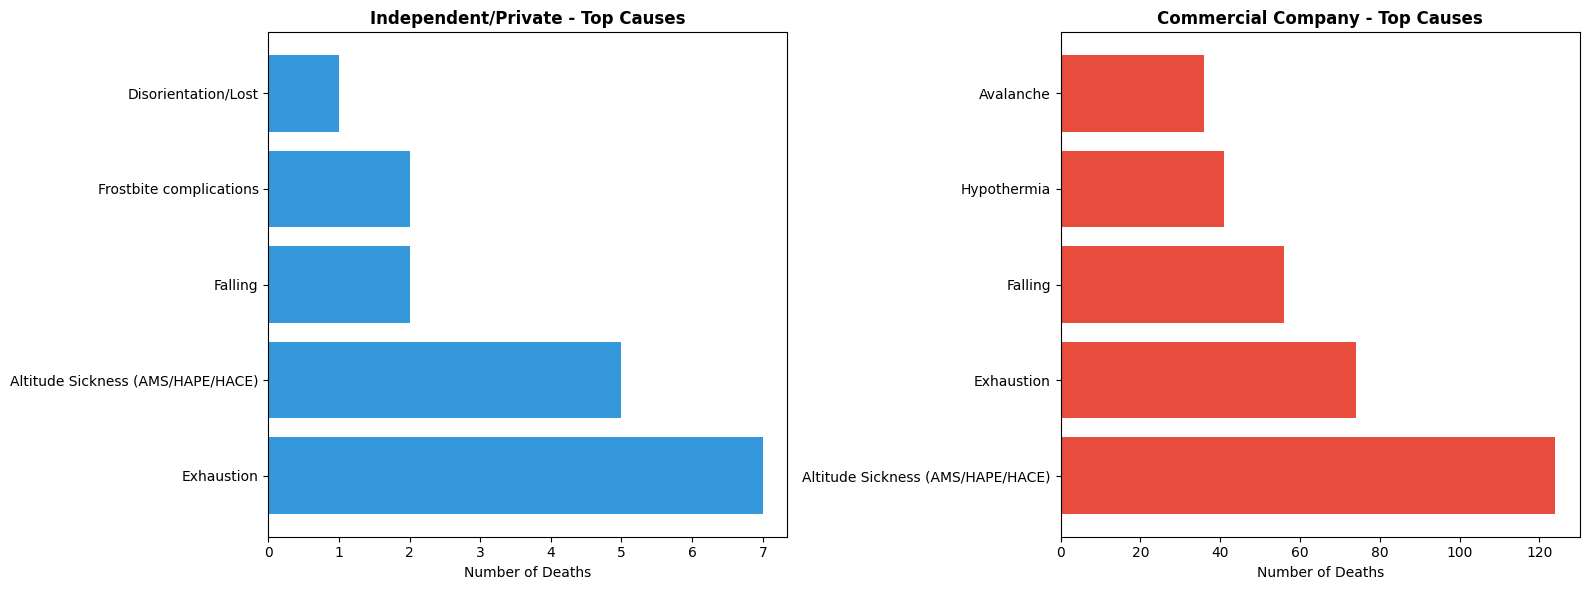

In [21]:
# 2. Cause of Death comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

commercial = everest20_25[everest20_25['expedition_type'] == 'Commercial Company']
independent = everest20_25[everest20_25['expedition_type'] == 'Independent/Private']

com_causes = commercial['Cause_of_Death'].value_counts().head(5)
ind_causes = independent['Cause_of_Death'].value_counts().head(5)

ax2.barh(com_causes.index, com_causes.values, color='#e74c3c')
ax2.set_title('Commercial Company - Top Causes', fontweight='bold')
ax2.set_xlabel('Number of Deaths')

ax1.barh(ind_causes.index, ind_causes.values, color='#3498db')
ax1.set_title('Independent/Private - Top Causes', fontweight='bold')
ax1.set_xlabel('Number of Deaths')

plt.tight_layout()

# Save plot
plt.savefig('images/everest_causes_by_expedition_type.png', dpi=300, bbox_inches='tight')
plt.show()

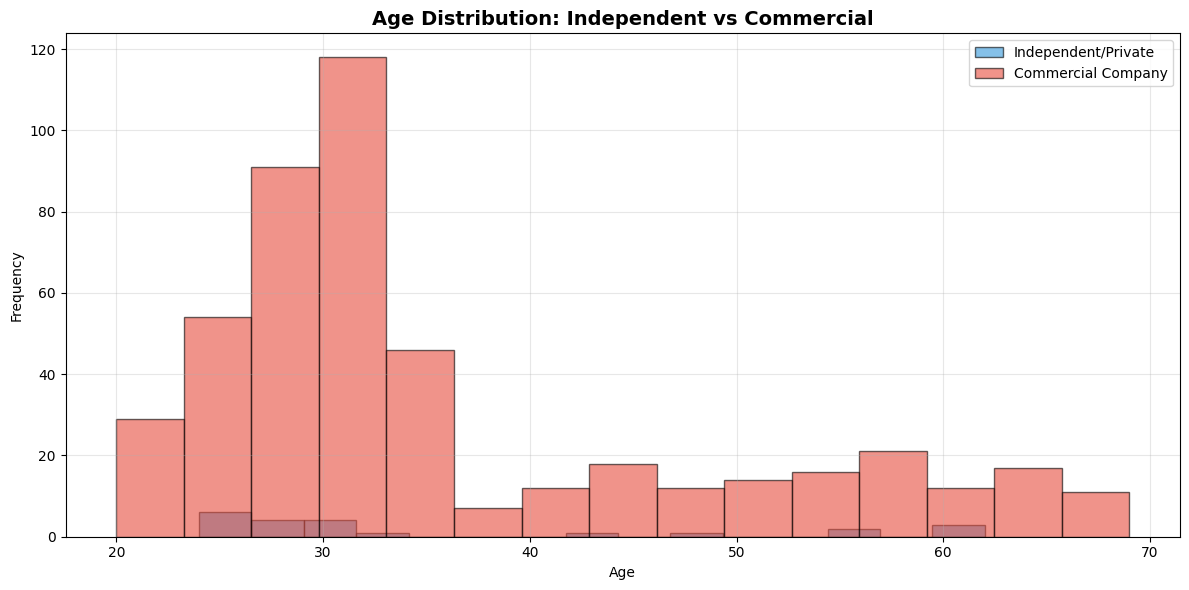

In [23]:
# 3. Age distribution comparison
fig, ax = plt.subplots(figsize=(12, 6))
independent['Age'].hist(bins=15, alpha=0.6, label='Independent/Private', color='#3498db', edgecolor='black')
commercial['Age'].hist(bins=15, alpha=0.6, label='Commercial Company', color='#e74c3c', edgecolor='black')
plt.title('Age Distribution: Independent vs Commercial', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save plot
plt.savefig('images/everest_age_distribution_expedition_type.png', dpi=300, bbox_inches='tight')
plt.show()

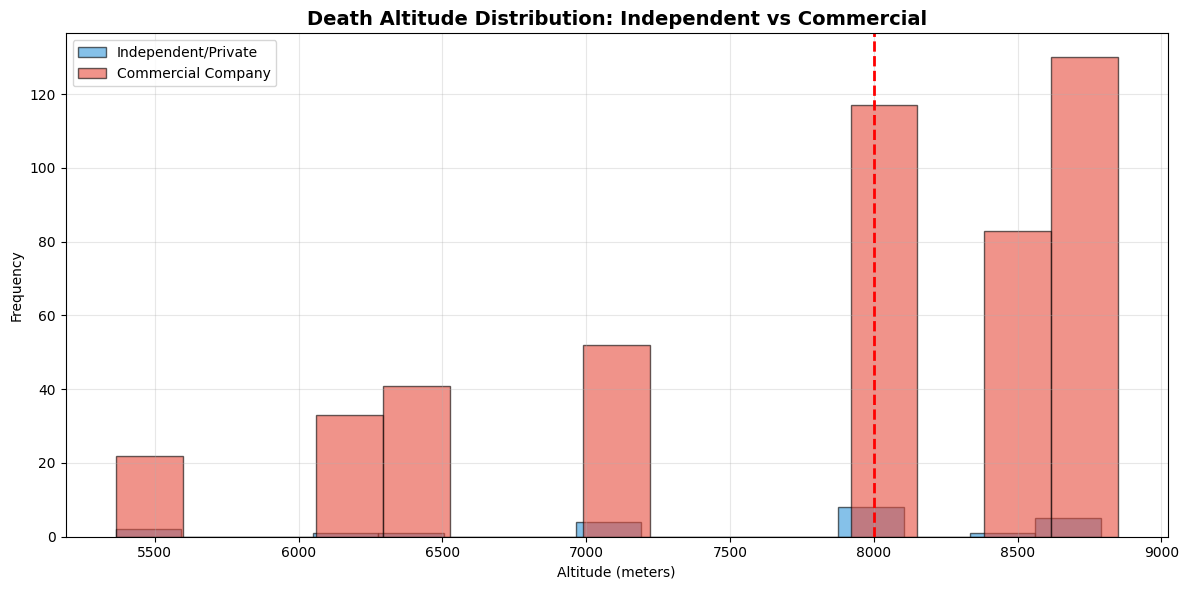

In [28]:
# 4. Altitude distribution
fig, ax = plt.subplots(figsize=(12, 6))
independent['Altitude_meters'].dropna().hist(bins=15, alpha=0.6, label='Independent/Private', color='#3498db', edgecolor='black')
commercial['Altitude_meters'].dropna().hist(bins=15, alpha=0.6, label='Commercial Company', color='#e74c3c', edgecolor='black')
plt.title('Death Altitude Distribution: Independent vs Commercial', fontsize=14, fontweight='bold')
plt.xlabel('Altitude (meters)')
plt.ylabel('Frequency')
plt.legend()
plt.axvline(8000, color='red', linestyle='--', linewidth=2, label='Death Zone (8000m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/everest_altitude_distribution_expedition_type.png', dpi=300, bbox_inches='tight')
plt.show()

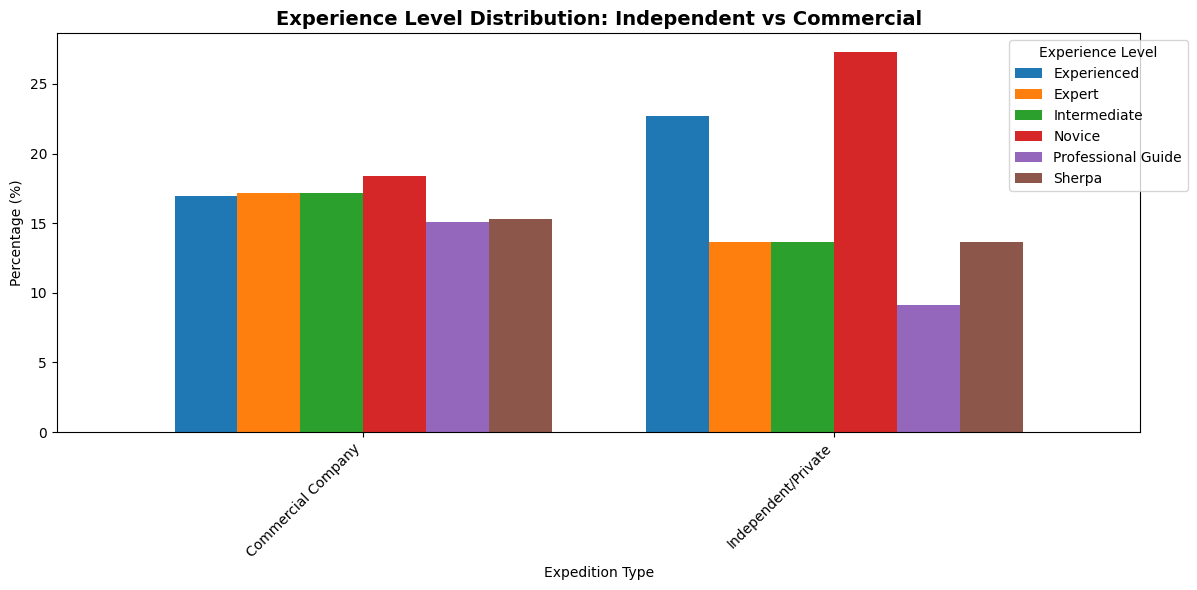

In [30]:
# 5. Experience Level comparison
fig, ax = plt.subplots(figsize=(12, 6))
exp_comparison = pd.crosstab(everest20_25['expedition_type'], 
                              everest20_25['Experience_Level'],
                              normalize='index') * 100
exp_comparison.plot(kind='bar', ax=ax, width=0.8)
plt.title('Experience Level Distribution: Independent vs Commercial', fontsize=14, fontweight='bold')
plt.xlabel('Expedition Type')
plt.ylabel('Percentage (%)')
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save plot
plt.savefig('images/everest_experience_expedition_type.png', dpi=300, bbox_inches='tight')
plt.show()